# Introduction to the Optical Eye Model: Anatomy, Materials, and Ray Tracing Theory

This notebook implements a **2D ray tracing simulation** of the human eye based on real optical data exported from Zemax. The goal is to understand how light propagates through the different structures of the eye – from the cornea to the retina – and to visualise the ray paths using Python.

Below we provide a self‑contained introduction to the anatomy, optical materials, and mathematical principles that underpin the code that follows.

## 1. Why model the eye optically?

A computational eye model allows us to study focusing, aberrations, and the effect of contact lenses or intraocular lenses without physical experiments. By rebuilding a Zemax model in Python, we gain complete control over every surface and can visualise the ray tracing step by step.

## 2. Basic anatomy from an optical perspective

Light enters the eye from the left (along the optical axis, labelled $z$) and passes through:

- **Cornea** – the transparent front surface. Radius of curvature ≈ $7.8$ mm, refractive index $n \approx 1.38$. It provides most of the eye’s focusing power.
- **Aqueous humor** – the fluid behind the cornea, $n \approx 1.34$.
- **Pupil** – the aperture stop of the eye, typically $1.25$ mm semi‑diameter in this model.
- **Crystalline lens** – a flexible lens with a **gradient refractive index (GRIN)**: the index is highest at the centre ($\approx 1.42$) and decreases towards the edges ($\approx 1.37$). This reduces spherical aberration.
- **Vitreous humor** – the gel‑like fluid filling the main cavity, $n \approx 1.34$.
- **Retina** – the image plane, often curved (radius $-12$ mm) where light is detected.

## 3. The Zemax data and its interpretation

The model is defined by a sequence of surfaces. Each surface has a radius of curvature $R$ (positive if the centre of curvature is to the left of the vertex, negative if to the right, infinite for a plane), a thickness (distance to the next surface), and refractive indices before and after the surface.

The table below translates the exported Zemax data into anatomical structures:

| Surface # | Anatomical part                | Radius (mm) | Thickness (mm) | Refractive index (n)     |
|-----------|--------------------------------|-------------|----------------|--------------------------|
| 0         | Object (at infinity)           | ∞           | $10^9$         | 1.0 (air)                |
| 1         | Dummy beam surface             | ∞           | 25.0           | 1.0 (air)                |
| 2         | Contact lens front surface     | 100.0       | 3.0            | 1.585 (polycarbonate)    |
| 3         | Contact lens back surface      | ∞ (plano)   | 25.0           | 1.0 (air)                |
| 4         | Cornea                         | 7.77        | 0.5            | 1.38                     |
| 5         | Aqueous humor                  | 6.40        | 3.16           | 1.34                     |
| 6         | Pupil (stop)                   | ∞           | 0.0            | (same as previous)       |
| 7         | Crystalline lens (front)       | 12.4        | 1.59           | GRIN (see below)         |
| 8         | Crystalline lens (back)        | ∞           | 2.43           | GRIN                     |
| 9         | Vitreous humor                 | -8.10       | 17.0           | 1.34                     |
| 10        | Retina (image plane)           | -12.0       | –              | –                        |

**Note:** The large $25$ mm air gaps are unusual for a real eye; they likely represent a laboratory setup. The code will reproduce the Zemax geometry exactly.

## 4. The Gradient‑Index (GRIN) crystalline lens

Unlike a homogeneous lens, the GRIN lens has a refractive index that varies with radial distance $r$ from the optical axis. In Zemax’s **Gradient 3** model, the index is given by a polynomial:

$$
n(r) = n_{00} + n_{01} r^2 + n_{02} r^4 + \cdots
$$

From the second data table, the coefficients for the front surface of the lens are:

- $n_{00} = 1.368$ (axial index)
- $n_{01} = -1.978 \times 10^{-3} \, \text{mm}^{-2}$ (quadratic term)
- $n_{02} = -0.016 \, \text{mm}^{-4}$ (quartic term)

Thus:

$$
n(r) = 1.368 - 0.001978\, r^2 - 0.016\, r^4
$$

The negative coefficients mean the index **decreases** away from the axis, which helps focus peripheral rays closer to the same point as paraxial rays – reducing spherical aberration.

The back surface of the lens has slightly different coefficients (axial index $1.407$), reflecting the natural gradient inside the lens.

## 5. Ray tracing theory: how the code works

The code traces each ray sequentially through all surfaces. For each step:

### 5.1 Intersection with a surface

The ray starts at a point $(z_{\text{ray}}, y_{\text{ray}})$ with direction angle $\theta$ measured from the $z$‑axis. Its path is described parametrically:

$$
\begin{aligned}
z(t) &= z_{\text{ray}} + t \cdot 1,\\
y(t) &= y_{\text{ray}} + t \cdot \tan\theta,
\end{aligned}
$$

with $t \ge 0$ (distance along $z$).

- **For a spherical surface** of radius $R$ whose vertex is at $z_s$, the centre is at $z_c = z_s - R$. Substituting into the circle equation $(z - z_c)^2 + y^2 = R^2$ gives a quadratic in $t$. The smallest positive root is the intersection point.
- **For a plane** ($R = \infty$), the intersection is simply $z = z_s$, and $y = y_{\text{ray}} + (z_s - z_{\text{ray}})\tan\theta$.

### 5.2 Refraction (Snell’s law)

At the intersection point, we compute the angle $\alpha$ of the surface normal relative to the $z$‑axis:

- Sphere: $\alpha = \arctan\left(\frac{y}{z - z_c}\right)$
- Plane: $\alpha = 0$

The incident angle relative to the normal is $\theta_i = \theta_{\text{ray}} - \alpha$. Snell’s law gives the transmitted angle:

$$
n_1 \sin\theta_i = n_2 \sin\theta_t \quad\Longrightarrow\quad \theta_t = \arcsin\!\left(\frac{n_1}{n_2}\sin\theta_i\right).
$$

The new ray direction is then:

$$
\theta_{\text{new}} = \alpha + \theta_t.
$$

If $\frac{n_1}{n_2}\sin\theta_i > 1$, total internal reflection occurs – the ray stops (though this rarely happens inside the eye).

### 5.3 Handling the GRIN lens (simplification in the first version)

A true GRIN would bend the ray continuously inside the lens. For simplicity, the first version of the code replaces the GRIN lens with a **homogeneous lens** whose index is the average of the front and back axial indices (approximately $1.3875$). This allows a working ray tracer with straight segments. A later extension can implement a multi‑layer slicing method for the full GRIN effect.

## 6. What the code does

The Python code that follows this markdown cell:

1. Defines each surface using the data above (positions, radii, indices).
2. Implements functions for sphere/plane intersection and Snell’s law.
3. Traces a set of parallel rays (from infinity) at different initial heights $y_0$ (e.g., from $-3$ mm to $+3$ mm).
4. Plots the 2D ray paths on a $z$‑$y$ plane, overlaying the surfaces as vertical lines.
5. Outputs a visualisation of how the eye model focuses light.

## 7. Possible extensions

- Implement the full GRIN lens by slicing it into many thin layers.
- Apply the pupil stop (surface 6) to block rays whose height exceeds the semi‑diameter $1.25$ mm.
- Compute the spot diagram on the retina.
- Adjust thicknesses to match a realistic human eye (e.g., shorter air gaps).



In [25]:
import matplotlib.pyplot as plt
import numpy as np
from math import tan

In [26]:
import numpy as np


N = 10
y0 = np.linspace(-3.0, 3.0, N)  # ray heights in mm 
tt = 0  # in radians

# Dummy beam
z1 = 0.0          # mm
t1 = 25.0         # mm
n1_s1 = 1.0
n2_s1 = 1.0
R1 = np.inf

# Contact lens front
z2 = z1 + t1      # 25.0 mm
t2 = 3.0          # mm
n1_s2 = 1.0
n2_s2 = 1.585
R2 = 100.0        # mm

# Contact lens back
z3 = z2 + t2      # 28.0 mm
t3 = 25.0         # mm
n1_s3 = 1.585
n2_s3 = 1.0
R3 = np.inf       # plano

# Cornea
z4 = z3 + t3      # 53.0 mm
t4 = 0.5          # mm
n1_s4 = 1.0
n2_s4 = 1.38
R4 = 7.77         # mm

# Aqueous humor
z5 = z4 + t4      # 53.5 mm
t5 = 3.16         # mm
n1_s5 = 1.38
n2_s5 = 1.34
R5 = 6.40         # mm

# Pupil (stop) 
z6 = z5 + t5      # 56.66 mm
t6 = 0.0          # no thickness
n1_s6 = 1.34
n2_s6 = 1.34      # same medium
R6 = np.inf
pupil_semi_diam = 1.25  # mm

# Crystalline lens (front)
z7 = z6 + t6      # 56.66 mm
t7 = 1.59         # mm
n1_s7 = 1.34

n_grin_avg = 1.3875  # average of 1.368 and 1.407
n2_s7 = n_grin_avg
R7 = 12.4         # mm

# Crystalline lens (back)
z8 = z7 + t7      # 58.25 mm
t8 = 2.43         # mm
n1_s8 = n_grin_avg
n2_s8 = 1.34
R8 = np.inf       # mm 

# SVitreous humor
z9 = z8 + t8      # 60.68 mm
t9 = 17.0         # mm
n1_s9 = 1.34
n2_s9 = 1.34
R9 = -8.10        # mm 

# Retina (image plane)
z10 = z9 + t9     # 77.68 mm
# no thickness beyond
n1_s10 = 1.34
n2_s10 = 1.34
R10 = -12.0       # curved retina


In [27]:
def propagate(y0, theta, z):
    return y0 + tan(theta) * z

def refraction_spherical(y1, tt, n1, n2, R):
    v1 = np.array([y1, tt])
    M = np.array([[1, 0], [-(n2-n1)/(n2*R), n1/n2]])
    v2 = M @ v1
    return v2[0], v2[1]

def refraction(y1, tt, n1, n2):
    v1 = np.array([y1, tt])
    M = np.array([[1, 0], [0, n1/n2]])
    v2 = M @ v1
    return v2[0], v2[1]

In [28]:
X_P = []   # list of z-segment pairs
Y_P = []   # list of y-segment pairs

for i in range(N):
    # ----- initial propagation 
    y1 = propagate(y0[i], tt, z2)                # height at z2
    X_P.append([z1, z2])
    Y_P.append([y0[i], y1])

    # Contact lens front 
    y2, tt2 = refraction_spherical(y1, tt, n1_s2, n2_s2, R2)   # height at z2
    y3 = propagate(y2, tt2, t2)                 
    X_P.append([z2, z3])
    Y_P.append([y1, y3])                   

    # Contact lens back 
    y4, tt3 = refraction_spherical(y3, tt2, n1_s3, n2_s3, R3)   # refraction at z3
    y5 = propagate(y4, tt3, t3)               
    X_P.append([z3, z4])
    Y_P.append([y3, y5])                       

    # Cornea 
    y6, tt4 = refraction_spherical(y5, tt3, n1_s4, n2_s4, R4)   # refraction at z4
    y7 = propagate(y6, tt4, t4)                
    X_P.append([z4, z5])
    Y_P.append([y5, y7])                        

    # Aqueous humor surface 
    y8, tt5 = refraction_spherical(y7, tt4, n1_s5, n2_s5, R5)   # refraction at z5
    y9 = propagate(y8, tt5, t5)                

    # Pupil 
    if abs(y9) > pupil_semi_diam:
        # Ray is blocked – stop tracing
        X_P.append([z5, z6])
        Y_P.append([y7, y9])                    # segment to the pupil

        continue                                 # skip further surfaces for this ray

    # Pupil refraction
    y10, tt6 = refraction_spherical(y9, tt5, n1_s6, n2_s6, R6) 
    y11 = propagate(y10, tt6, t6)              

    # Crystalline lens front 
    y12, tt7 = refraction_spherical(y11, tt6, n1_s7, n2_s7, R7)
    y13 = propagate(y12, tt7, t7)             

    # Crystalline lens back 
    y14, tt8 = refraction_spherical(y13, tt7, n1_s8, n2_s8, R8)   
    y15 = propagate(y14, tt8, t8)              

    # Vitreous humor surface
    y16, tt9 = refraction_spherical(y15, tt8, n1_s9, n2_s9, R9)
    y17 = propagate(y16, tt9, t9)              

    # ----- append remaining segments 
    # append the aqueous–pupil segment yet for non-blocked rays.

    X_P.append([z5, z6])
    Y_P.append([y7, y9])                       

    # Pupil to z7 
    X_P.append([z6, z7])
    Y_P.append([y9, y11])                       

    # z7 to z8 
    X_P.append([z7, z8])
    Y_P.append([y11, y13])

    # z8 to z9
    X_P.append([z8, z9])
    Y_P.append([y13, y15])

    # z9 to z10 (retina)
    X_P.append([z9, z10])
    Y_P.append([y15, y17])

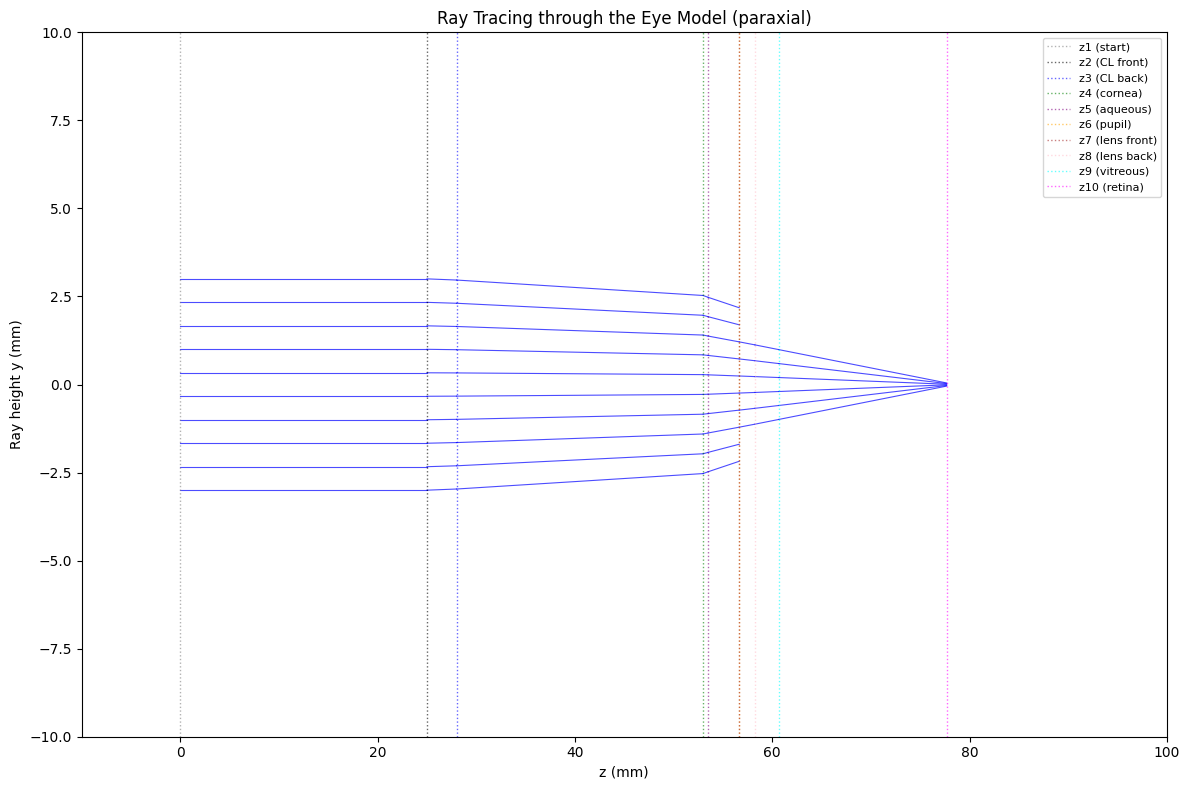

In [29]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Plot 
plt.figure(figsize=(12, 8))

# Plot all ray 
for xs, ys in zip(X_P, Y_P):
    plt.plot(xs, ys, 'b-', linewidth=0.8, alpha=0.7)

# Surface markers
surface_z = [z1, z2, z3, z4, z5, z6, z7, z8, z9, z10]
surface_labels = ['z1 (start)', 'z2 (CL front)', 'z3 (CL back)', 
                  'z4 (cornea)', 'z5 (aqueous)', 'z6 (pupil)',
                  'z7 (lens front)', 'z8 (lens back)', 'z9 (vitreous)', 'z10 (retina)']


colors = ['gray', 'black', 'blue', 'green', 'purple', 'orange', 
          'brown', 'pink', 'cyan', 'magenta']


surface_lines = []
for z, label, color in zip(surface_z, surface_labels, colors):
    line = plt.axvline(x=z, color=color, linestyle=':', linewidth=1.0, alpha=0.6)
    surface_lines.append((line, label))   # store for legend


legend_handles = []

for line, label in surface_lines:
    legend_handles.append(Line2D([0], [0], color=line.get_color(), linestyle=':', 
                                 linewidth=1.0, alpha=0.6, label=label))


plt.legend(handles=legend_handles, loc='upper right', fontsize=8)

# Labels and title
plt.xlabel('z (mm)')
plt.ylabel('Ray height y (mm)')
plt.title('Ray Tracing through the Eye Model (paraxial)')

plt.ylim(-10, 10)
plt.xlim(-10,100)

plt.tight_layout()
plt.show()